# Tutorial

To illustrate how to use the library, we will consider the following regression problem :

$$ y = X\beta +\varepsilon, \varepsilon\sim\mathcal{N}(0,\sigma^2I_{M}) $$


### Data generation

In [16]:
import numpy as np


def generate_data(sample_size: int, dimension: int, seed: int, intercept=0.0):
    r"""Generate synthetic data with controlled ground truth for a sparse linear
    regression problem.

    Parameters
    ----------
    sample_size : int
        Number of observed data samples.
    dimension : int
        Dimension of each sample.
    seed : int
        Seed to initialize the random number generator used to generate the
        data.
    intercept : float, optional
        Value of the intercept vector :math:`\mu`, by default 0.

    Returns
    -------
    X : numpy.ndarray
        Matrix whose rows are the data samples.
    y : numpy.ndarray
        Observation to be analyzed.
    beta_true : numpy.ndarray
        Ground thruth value for the regression vector :math:`\beta`.
    noise_std : float
        Ground truth value for the standard deviation of the Gaussian noise.
    support : numpy.ndarray[bool]
        Array of boolean indicating the support of the ground truth vector
        :math:`\beta`.
    """
    rng = np.random.default_rng(seed)

    # set up parameters
    noise_std = 1
    proportion_of_nonzero_coefficients = 0.1
    signal_absolute_value = 10

    # prepare containers to return
    beta_true = rng.normal(0.0, 0.25, size=(dimension,))
    support = rng.choice(
        2,
        size=(dimension,),
        p=[
            1 - proportion_of_nonzero_coefficients,
            proportion_of_nonzero_coefficients,
        ],
    )
    id_support = np.flatnonzero(support)
    positive_peaks_position = rng.choice(2, size=id_support.shape, p=[0.5, 0.5])

    beta_true[id_support] = -signal_absolute_value + rng.standard_normal(
        size=id_support.shape
    )
    beta_true[id_support[positive_peaks_position.astype(bool)]] += (
        2 * signal_absolute_value
    )

    X = rng.normal(0, 1, (sample_size, dimension))
    y = rng.normal(X @ beta_true + intercept, noise_std)

    return X, y, beta_true, noise_std, np.where(support)[0]

In [17]:
dimension = 100  # size of beta_true
sample_size = 50  # size of y
X, y, beta_true, sigma_noise, indices_support = generate_data(
    sample_size=sample_size, dimension=dimension, seed=3
)

## First approach
With the an $L^{1}$ penalty, the targeted law writes as follows : 

$$p(\beta|y)~ \sim~exp(-\frac{1}{2\sigma^2} \mid\mid y - X\beta \mid\mid_2^2 -\lambda \mid\mid \beta \mid\mid_1 )$$

The density of this law of probability can be associated to a potential. This potential being non-smooth, we can assume that this law can not be sampled by the usual means.
Instead, we can use Langevin algorithms to generate a Markov chain that will approximate this target law.

In order to sample according to this probability law using this library, the user must define its own model. To do so, we create a new model that inherit from a base model, we must then overwrite the virtual methods of the mother interface class.


### Model definition

In [18]:
from mcmc.models.base_model import BaseModel
from mcmc.estimator.mmse_builder import mmse_builder


class bayesian_lasso_model(BaseModel):
    def __init__(self, sigma, lam, X, beta):
        # model parameters
        self.sigma = sigma
        self.lam = lam
        self.X = X
        # transition kernel
        self.beta = beta

        self.estimator_builder = mmse_builder(self.beta.current_state.shape)

    def update(self, rng):
        # single kernel model
        self.beta.mc_step(rng)

    def get_states(self):
        # describe which variables must be save in the outpout file
        states = {}
        states["beta"] = self.beta.get_state()
        states["MMSE"] = self.estimator_builder.estimator
        return states

    def set_states(self, beta):
        self.beta.current_state = beta

    def compute_potential(self):
        p = (
            0.5
            / self.sigma**2
            * np.linalg.norm(y - np.matmul(self.X, self.beta.current_state), ord=2) ** 2
        )
        p += self.lam * np.sum(np.abs(self.beta.current_state))
        return p

    def aggregate_states(self):
        self.estimator_builder.aggregate_states(self.beta.current_state)

    # the two following method are only needed when we want to save all the states of the chain, it drasticaly decreases the performances
    def get_states4batch(self):
        states = {}
        states["beta"] = self.beta.current_state
        return states

    def get_batch_sizes(self):
        sizes = {}
        sizes["beta"] = self.beta.current_state.shape
        return sizes

### Drawing samples from the posterior distribution
#### Set parameters

In [19]:
from mcmc.transition_kernel.psgla import PSGLA
from mcmc.sampler.serial_sampler import SerialSampler, SamplerParameters
from os.path import exists
from os import makedirs
from mcmc.functionals.prox import prox_l1norm
import logging

dimension = 100
nsamples = 5000
nb_batches = 5
batch_size = nsamples // nb_batches
seed = 1234

if not exists("data"):
    makedirs("data")

if not exists("data/psgla_bayesian_lasso"):
    makedirs("data/psgla_bayesian_lasso")

reg_coeff = 5e-2

sampler_params = SamplerParameters(
    batch_size, nb_batches, seed, "sample", "data/psgla_bayesian_lasso"
)

logger = logging.getLogger(__name__)
logging.basicConfig(
    filename="bayesian_lasso_log",
    level=logging.INFO,
    filemode="w",
    format="%(asctime)s %(levelname)s %(message)s",
)

#### Instanciate transition kernel and sampler

In [20]:
# build an instance of a transition kernel
beta = PSGLA(dimension, 0.99 * sigma_noise**2 / np.linalg.norm(X, ord=2) ** 2)
# set its behaviour
beta.prox = lambda z: prox_l1norm(z, reg_coeff)
beta.grad = lambda z: X.T @ (X @ z - y) / sigma_noise**2

# build an instance of the model
model = bayesian_lasso_model(sigma_noise, reg_coeff, X, beta)

# build a sampler
sampler = SerialSampler(sampler_params, model, logger, save_full_batch=True)

In [21]:
# run the sampler
sampler.sample()

Sampling: 6it [00:00, 17.11it/s]                       


### Post-processing : estimates and reconstruction metrics

In [22]:
def compute_snr(recons, truth):
    return 20 * np.log(np.linalg.norm(truth) / np.linalg.norm(truth - recons))

In [29]:
from os.path import join
import h5py
import matplotlib.pyplot as plt


def plot_results(path, data_thruth, sample_size, nb_batches):
    potential = np.zeros(sample_size)
    mmse = np.zeros_like(data_thruth)
    full_batch = np.zeros((sample_size, *data_thruth.shape))
    for i in range(1, nb_batches + 1):
        file_name = join(path, "sample" + str(i) + ".h5")
        with h5py.File(file_name) as file:
            mmse += file["MMSE"]

            potential[(i - 1) * batch_size : i * batch_size] = file["potential"][:]
            full_batch[(i - 1) * batch_size : i * batch_size, ...] = file["batch/beta"][
                :
            ]
    mmse = mmse / nb_batches
    plt.figure()
    plt.plot(mmse, label="estimation")
    plt.plot(beta_true, label="truth")
    plt.title("Reconstruction")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(np.abs(mmse - data_thruth))
    plt.title("Absolute value of the error")
    plt.show()

    plt.figure()
    plt.plot(potential)
    plt.title("Potential")
    plt.show()

    quantile = np.quantile(full_batch, (0.25, 0.75), axis=0)
    plt.figure()
    plt.plot(mmse[-15:], label="estimator")
    plt.plot(quantile[0, -15:], label="q_25", color="green")
    plt.plot(quantile[1, -15:], label="q_75", color="red")
    plt.legend()
    plt.title(r"Credible interval (last 15 values of $\beta$)")
    plt.show()

    plt.figure()
    autocorr = np.correlate(full_batch[:, 0], full_batch[:, 0], "same")
    plt.plot(autocorr[sample_size // 2 :] / np.amax(autocorr))
    plt.title("Autocorrelation")
    plt.show()

    print("SNR estimate/truth : ", compute_snr(mmse, data_thruth))

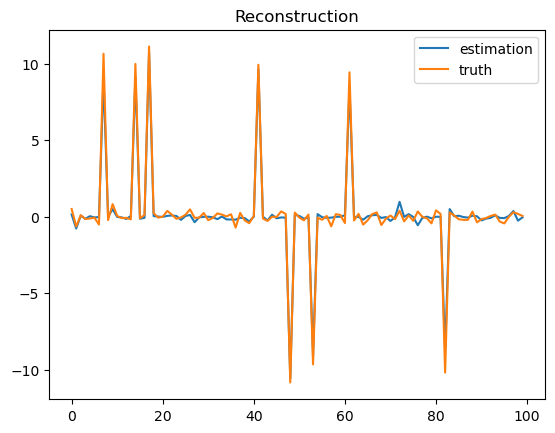

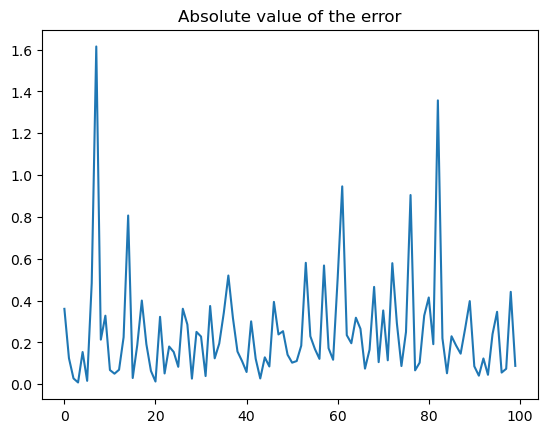

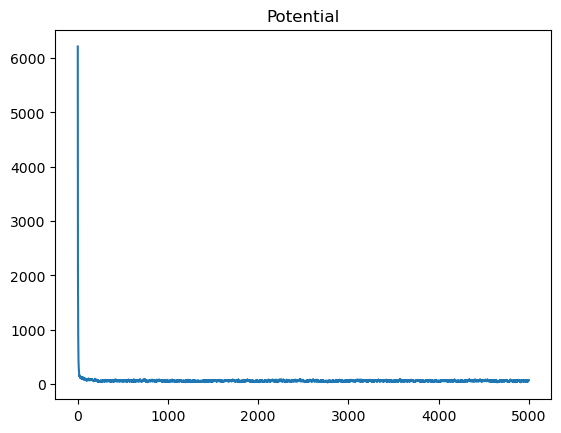

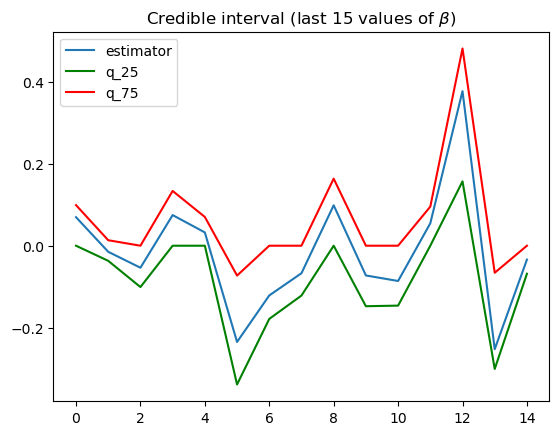

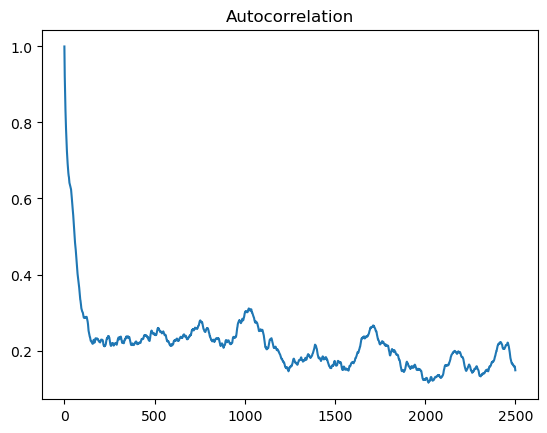

SNR estimate/truth :  41.96641278586935


In [31]:
plot_results("data/psgla_bayesian_lasso", beta_true, nsamples, nb_batches)

### Change Kernel type

For this estimation, we used the PSGLA algorithm. But, the model we have defined does not expect a specific type of transition kernel. If we want to, we can use another kind of transition kernel and use the same model and sampler.

In [32]:
from mcmc.transition_kernel.myula import MYULA

if not exists("data/myula_bayesian_lasso"):
    makedirs("data/myula_bayesian_lasso")

reg_coeff = 5e-2
lipschitz_cst = 0.5 * np.linalg.norm(X, ord=2) ** 2 / sigma_noise**2

# build another kernel
beta = MYULA(dimension, lipschitz_cst, 1, step_factor=0.5)
# set its behaviour
beta.prox = lambda z: prox_l1norm(z, reg_coeff)
beta.grad = lambda z: X.T @ (X @ z - y) / sigma_noise**2

# modify the already existing model to use the new kernel
model.beta = beta

sampler.save_path = "data/myula_bayesian_lasso"

In [33]:
# run the sampler
sampler.sample()

Sampling: 6it [00:00, 18.66it/s]                       


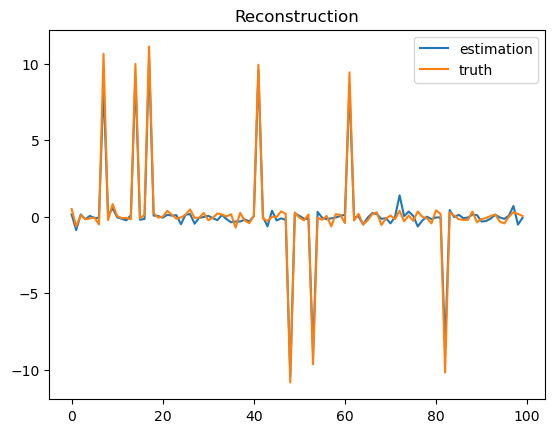

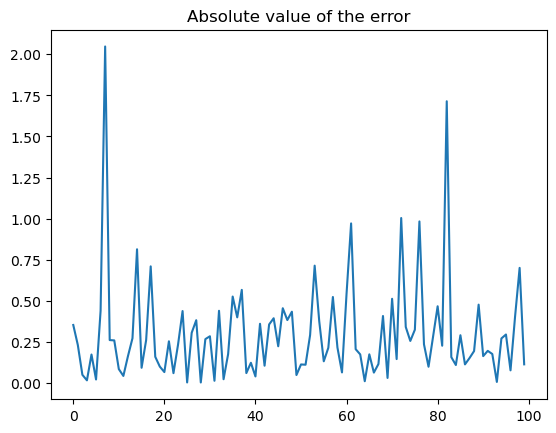

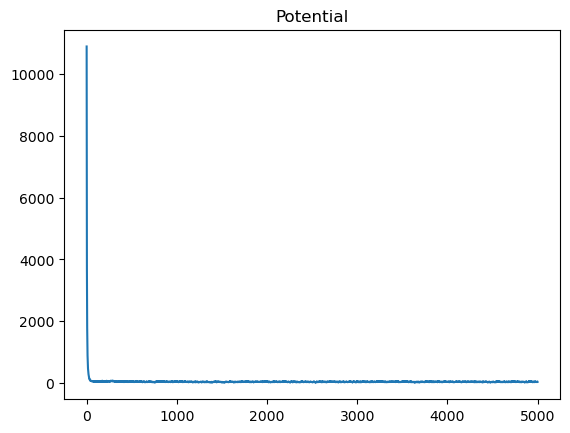

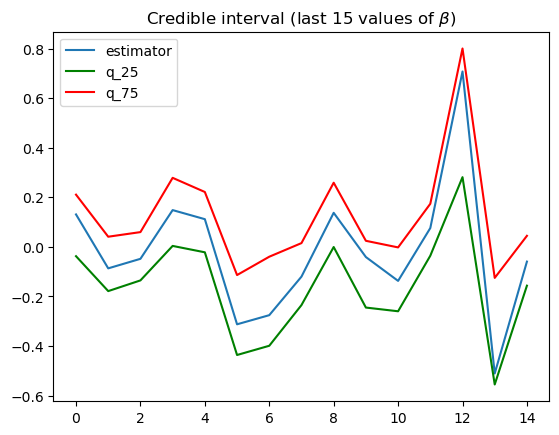

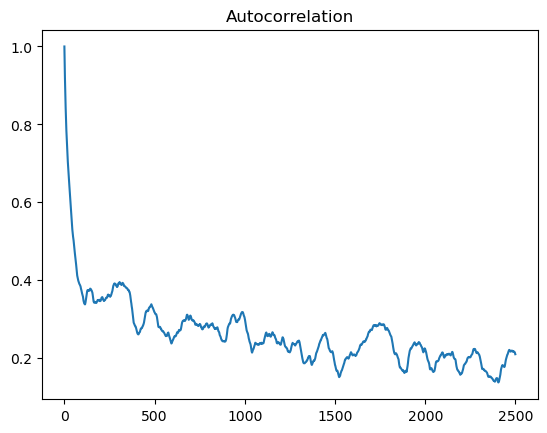

SNR estimate/truth :  38.07392376781559


In [34]:
plot_results("data/myula_bayesian_lasso", beta_true, nsamples, nb_batches)

# Second approach
## Augmented bayesian lasso

With a more in-depth study of the problem, we can propose, by introducing an intermediary variable $\tau$, the following hirachical model ([Bayesian Lasso, Park and Casella 2008](https://people.eecs.berkeley.edu/~jordan/courses/260-spring09/other-readings/park-casella.pdf)):

$$p(\beta|y,\tau) \sim exp(-\frac{1}{2\sigma^2}\mid\mid X\beta-y \mid\mid_2^2 -\frac{1}{2}\mid\mid \beta \mid\mid^2_{\sigma^2 D_{\tau}}-\frac{\lambda}{2}\mid\mid \tau \mid\mid_2^2) \text{, where } D_{\tau} = diag(\tau_j)$$

$$ p(\beta| \tau) \sim \mathcal{N}(0,\sigma^2 D_{\tau}) $$

$$ p(\tau) \sim \displaystyle{\prod_{j=1}^M} \dfrac{\lambda^2}{2}e^{-\lambda^2\tau_j^2}d\tau_j$$

By integrating accordingly, we can deduce the following conditionnal laws. The specific structure of the multivariate gaussian law can be exploited 
for faster computations ([Bhattacharya2016](https://arxiv.org/abs/1506.04778)):

$$ p(\tau_j| y, \beta) \sim  Wald\left(\mu = \sqrt{ \dfrac{\lambda^2\sigma^2}{\beta_j} }, \lambda = \lambda^2\right)$$

$$ p(\beta | \tau, y) \sim \mathcal{N} (S, m ), S = (\Phi^T \Phi+ D_{\tau})^{-1}, \Phi = \dfrac{1}{\sigma} X, m = S\Phi^T\alpha, \alpha= \dfrac{1}{\sigma}y$$

At this point, all the intermediary variables are following usual probability laws (inverse gaussian, multivariate gaussian) tha can be sampled without using the approximation of a Langevin algorithm.
It is possible to sample the targeted law by using a Gibbs sampler. This is actually easier to code with our library, we just need to describe the update of the Gibbs sampler in the model and use  the usual library to draw the values of the variables (which follow usual laws). 

## Define another model

In [35]:
class augmented_bayesian_lasso(BaseModel):
    def __init__(self, sigma, y, lam, X, beta, tau2):
        # model parameters
        self.sigma = sigma
        self.lam = lam
        self.X = X
        self.tau2 = tau2
        self.phi = self.X / self.sigma
        self.alpha = y / self.sigma
        # buffer for the random variable
        self.beta = beta

        self.estimator_builder = mmse_builder(self.beta.shape)

    def update(self, rng):
        # update mechanism described in the atricle
        u = np.sqrt(self.tau2) * rng.normal(scale=1, size=self.tau2.shape)
        nu = self.phi @ u + rng.normal(size=self.phi.shape[0])
        w = np.linalg.solve(
            self.phi @ (self.tau2[:, None] * self.phi.T)
            + np.identity(self.phi.shape[0]),
            self.alpha - nu,
        )
        # linear solve more efficient with scipy, can use symmetry
        self.beta = u + self.tau2 * (self.phi.T @ w)

        self.tau2 = 1.0 / rng.wald(
            self.sigma * self.lam / np.abs(self.beta), self.lam**2
        )

    def get_states(self):
        states = {}
        states["beta"] = self.beta
        states["tau2"] = self.tau2
        states["MMSE"] = self.estimator_builder.estimator
        return states

    def set_states(self, data):
        self.beta = data["beta"]
        self.tau2 = data["tau2"]

    def compute_potential(self):
        p = (
            0.5
            / self.sigma**2
            * np.linalg.norm(y - np.matmul(X, self.beta), ord=2) ** 2
        )
        p += 0.5 * np.sum(1 / (self.sigma**2 * self.tau2) * self.beta**2)
        p += 0.5 * self.lam * np.sum(self.tau2)
        return p

    def aggregate_states(self):
        self.estimator_builder.aggregate_states(self.beta)

    def get_states4batch(self):
        states = {}
        states["beta"] = self.beta
        return states

    def get_batch_sizes(self):
        sizes = {}
        sizes["beta"] = self.beta.shape
        return sizes

## Drawing samples from the posterior distribution

#### Set parameters

In [36]:
dimension = 100

nsamples = 5000
nb_batches = 5
batch_size = nsamples // nb_batches
seed = 1234
if not exists("data"):
    makedirs("data")

if not exists("data/augmented_bayesian_lasso"):
    makedirs("data/augmented_bayesian_lasso")

reg_coeff = 2e1

sampler_params = SamplerParameters(
    batch_size, nb_batches, seed, "sample", "data/augmented_bayesian_lasso"
)

logger = logging.getLogger(__name__)
logging.basicConfig(
    filename="bayesian_lasso_log",
    level=logging.INFO,
    filemode="w",
    format="%(asctime)s %(levelname)s %(message)s",
)

#### Instanciate model and sampler

In [37]:
# set an intial value
tau2 = np.random.exponential(2 / reg_coeff**2, size=beta_true.shape)
# build the model, no transition kernel involved this time
model = augmented_bayesian_lasso(sigma_noise, y, reg_coeff, X, beta_true, tau2)

# build a sampler
sampler = SerialSampler(sampler_params, model, logger, save_full_batch=True)

In [38]:
# run the sampler
sampler.sample()

Sampling: 6it [00:02,  2.42it/s]                       


## Analyze the generated data

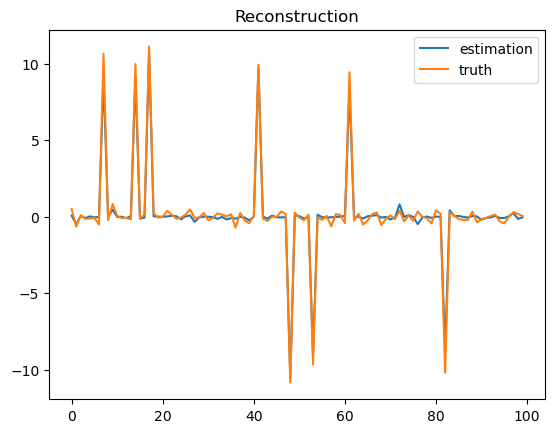

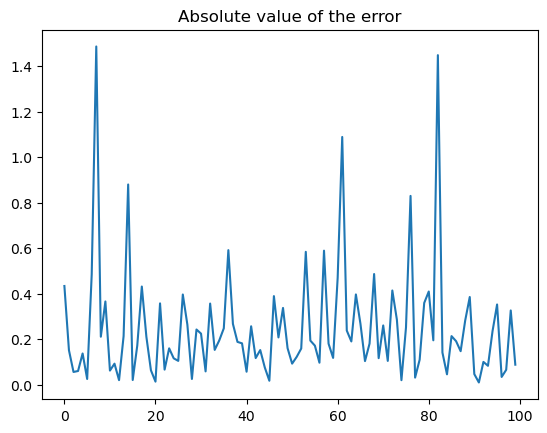

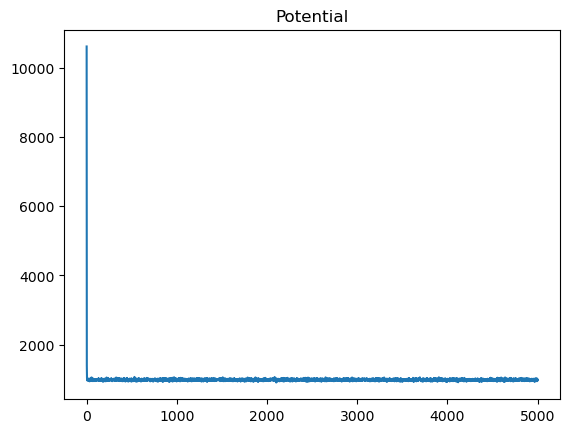

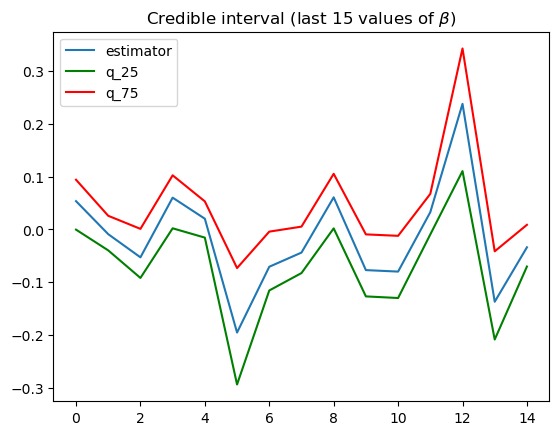

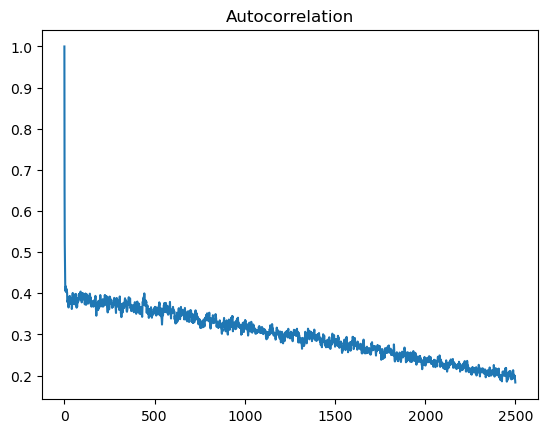

SNR estimate/truth :  41.93732500490421


In [39]:
plot_results("data/augmented_bayesian_lasso", beta_true, nsamples, nb_batches)

### References

1. [Bayesian Lasso, Park and Casella 2008](https://people.eecs.berkeley.edu/~jordan/courses/260-spring09/other-readings/park-casella.pdf)
2. [Bhattacharya2016](https://arxiv.org/abs/1506.04778)